<a href="https://colab.research.google.com/github/LucasPuertas95/Procesamiento-del-Habla/blob/main/TP2_webscrapping_preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 PROCESAMIENTO DEL HABLA

**Escriba aquí su nombre completo.**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [36]:
import requests
from bs4 import BeautifulSoup

#  El enlase sobre la noticia
enlace_web = "https://www.lanacion.com.ar/ciencia/es-oficial-la-nasa-ya-tiene-fecha-para-la-mision-artemis-que-bajara-a-la-luna-nid20042026/"
cabeceras = {'User-Agent': 'Mozilla/5.0'}

respuesta_web = requests.get(enlace_web, headers=cabeceras)
respuesta_web.encoding = 'utf-8'
sopa_datos = BeautifulSoup(respuesta_web.text, 'html.parser')

parrafos_noticia = sopa_datos.find_all('p', class_='com-paragraph')
texto_unido = " ".join([p.get_text() for p in parrafos_noticia])

print("--- Texto descargado con éxito ---")

--- Texto descargado con éxito ---


Este script ejecuta un web scraping mediante la librería requests para descargar el HTML de una noticia, enviando una cabecera User-Agent que evita restricciones de acceso. Tras forzar la codificación utf-8 para evitar errores en caracteres especiales, el objeto BeautifulSoup procesa el documento para localizar selectivamente todas las etiquetas <p> con la clase com-paragraph. El procedimiento concluye extrayendo el contenido limpio con .get_text() y unificándolo mediante .join() en una sola cadena de texto, eliminando así cualquier estructura HTML residual.

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [37]:
import spacy

# Aqui se carga el modelo en español de spacy
procesador_idioma = spacy.load("es_core_news_sm")

# Uso la variable que ya contenía el texto del scraping anterior
documento = procesador_idioma(texto_unido.lower())

# Se extraen las palabras vacías presentes en el discurso
vacias_encontradas = [token.text for token in documento if token.is_stop]

print("--- Stop-Words detectadas con spaCy ---")
print(list(set(vacias_encontradas))[:70])

--- Stop-Words detectadas con spaCy ---
['porque', 'por', 'de', 'esta', 'mediante', 'con', 'sus', 'nuevos', 'según', 'la', 'en', 'dos', 'las', 'pero', 'tiene', 'fin', 'aunque', 'o', 'para', 'este', 'su', 'deben', 'el', 'al', 'ese', 'también', 'un', 'del', 'sin', 'fuera', 'uso', 'uno', 'propia', 'menos', 'estas', 'muy', 'total', 'una', 'otro', 'todavía', 'que', 'y', 'respecto', 'aquella', 'los', 'realizar', 'antes', 'más', 'ocho', 'gran', 'lado', 'a']


Este script realiza el procesamiento de lenguaje natural (NLP) para identificar términos gramaticales irrelevantes o stop-words. Utiliza spacy.load para inicializar un modelo lingüístico en español que analiza el texto previamente normalizado en minúsculas. El procedimiento recorre el documento evaluando la propiedad booleana .is_stop de cada token, lo que permite filtrar palabras frecuentes (como preposiciones o artículos) que no aportan carga semántica al análisis. Finalmente, se eliminan duplicados mediante set() y se visualiza una muestra representativa de los términos detectados.

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

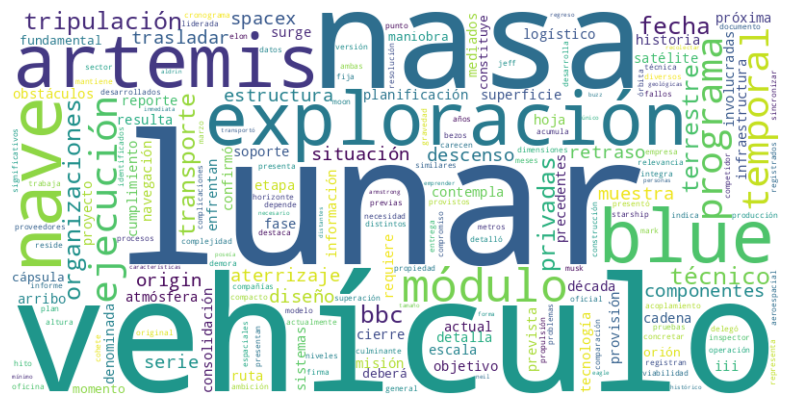

In [38]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# Filtro el documento de spaCy para quitar stop words y signos de puntuación
palabras_limpias = [token.text for token in documento if not token.is_stop and not token.is_punct]
texto_final_nube = " ".join(palabras_limpias)

# Aqui uso una paleta de colores de Seaborn para la estética
paleta_colores = sns.color_palette("viridis", as_cmap=True)

# Creacion de la nube de palabras
nube_artemis = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap=paleta_colores
).generate(texto_final_nube)

plt.figure(figsize=(10, 5))
plt.imshow(nube_artemis, interpolation='bilinear')
plt.axis("off")
plt.show()

Aqui se genera una nube de palabras para visualizar la relevancia léxica del texto. Primero, filtra el documento eliminando stop-words y puntuación mediante los atributos .is_stop e .is_punct. Luego, la clase WordCloud procesa la cadena resultante aplicando una paleta de seaborn para la estética. El procedimiento finaliza con matplotlib, que proyecta la imagen y oculta los ejes para una visualización limpia.

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Obtengo las oraciones que spaCy ya identificó en el 'documento'
lista_de_oraciones = [oracion.text.strip() for oracion in documento.sents]

# 2. Obtengo la lista de stop words de spaCy
palabras_vacias_lista = list(procesador_idioma.Defaults.stop_words)

# 3. Creo la matriz de conteo (frecuencia de términos)
vectorizador_conteo = CountVectorizer(stop_words=palabras_vacias_lista)
matriz_conteo_datos = vectorizador_conteo.fit_transform(lista_de_oraciones)

# 4. Convierto a una tabla (DataFrame) para visualizarla
tabla_vocabulario = pd.DataFrame(
    matriz_conteo_datos.toarray(),
    columns=vectorizador_conteo.get_feature_names_out()
)

print("--- Matriz Documento-Vocabulario (Conteo) ---")
print(f"Dimensiones: {tabla_vocabulario.shape[0]} oraciones x {tabla_vocabulario.shape[1]} palabras.")
display(tabla_vocabulario.head(100)) # Muestra las primeras filas de la tabla

--- Matriz Documento-Vocabulario (Conteo) ---
Dimensiones: 23 oraciones x 226 palabras.


,10,1969,2024,2027,35,acoplamiento,actual,actuales,actualmente,acumula,...,tripulación,técnica,técnico,técnicos,vehículo,vehículos,versión,viabilidad,órbita,único
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
9,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0


Este script construye una matriz para cuantificar la frecuencia de palabras por oración. El proceso inicia segmentando el texto original en oraciones individuales mediante el atributo .sents de spaCy. Luego, utiliza CountVectorizer para transformar estas oraciones en vectores numéricos, aplicando automáticamente el filtrado de stop words del modelo de idioma. Finalmente, el método .fit_transform() genera la matriz de conteo, la cual se convierte en un DataFrame de pandas para estructurar la relación entre cada oración (filas) y el vocabulario único detectado (columnas).


#### 2.3.2 Determina la longitud de tu vocabulario.

In [40]:
# Aqui se suman las apariciones de cada palabra en todas las oraciones para saber su frecuencia, quise agregarlo
frecuencia_palabras = tabla_vocabulario.sum(axis=0).sort_values(ascending=False)

# Longitud del vocabulario
vocabulario_longitud = len(frecuencia_palabras)

print(f"--- Longitud del Vocabulario: {vocabulario_longitud} ")
print("--- Palabras más frecuentes en el vocabulario ---")
print(frecuencia_palabras.head(10))


--- Longitud del Vocabulario: 226 
--- Palabras más frecuentes en el vocabulario ---
lunar          4
blue           3
exploración    3
vehículos      3
nasa           3
artemis        3
diseño         2
aterrizaje     2
fecha          2
bbc            2
dtype: int64


suma los conteos de la matriz usando .sum(axis=0) para ver cuántas veces aparece cada palabra en total y las ordena de mayor a menor. El procedimiento calcula la longitud del vocabulario contando el tamaño de la serie resultante con len(). Para cerrar, usa sns.barplot() para dibujar un gráfico de barras horizontal que muestra visualmente cuáles son los 10 términos que más peso tienen en el texto.


#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Se inicializa el vectorizador TF-IDF
vectorizador_tfidf = TfidfVectorizer(stop_words=palabras_vacias_lista)

# 2. Aqui transformo las oraciones
matriz_tfidf_datos = vectorizador_tfidf.fit_transform(lista_de_oraciones)

longitud_vocabulario_tfidf = len(vectorizador_tfidf.get_feature_names_out())

# 3. Creo la tabla final de pesos
tabla_tfidf = pd.DataFrame(
    matriz_tfidf_datos.toarray(),
    columns=vectorizador_tfidf.get_feature_names_out()
)

print("--- Matriz con pesos TF-IDF aplicada ---")
# Mostramos las palabras con mayor relevancia en la oración número 1
print("Palabras con mayor peso (importancia) en la primera oración:")
print(tabla_tfidf.iloc[0].sort_values(ascending=False).head(5))

# Visualización de la tabla TF-IDF
print(f"--- Matriz TF-IDF (Vocabulario: {longitud_vocabulario_tfidf} palabras) ---")
display(tabla_tfidf.head(100))

--- Matriz con pesos TF-IDF aplicada ---
Palabras con mayor peso (importancia) en la primera oración:
etapa            0.336888
confirmó         0.336888
próxima          0.336888
planificación    0.336888
ejecución        0.297691
Name: 0, dtype: float64
--- Matriz TF-IDF (Vocabulario: 226 palabras) ---


,10,1969,2024,2027,35,acoplamiento,actual,actuales,actualmente,acumula,...,tripulación,técnica,técnico,técnicos,vehículo,vehículos,versión,viabilidad,órbita,único
0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.319751,0.000000,0.000000,0.000000,...,0.282548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.253496,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.00000,0.000000,0.000000,0.349142,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.00000,0.000000,0.000000,0.000000,0.000000,0.271546,0.000000,0.000000,0.000000,0.000000,...,0.239952,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.271546,0.000000
6,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.257993,0.000000,0.000000,0.000000,0.000000
9,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.249042,0.000000,...,0.000000,0.000000,0.000000,0.249042,0.000000,0.000000,0.000000,0.249042,0.000000,0.000000


Este script calcula la relevancia estadística de cada palabra usando el algoritmo TF-IDF. El procedimiento utiliza .fit_transform() para penalizar palabras muy comunes y resaltar las que dan contexto único a cada oración. Para sacar la longitud del vocabulario, usa get_feature_names_out() que extrae los términos únicos (sin repetir y sin stop words) y len() para darte el número total de columnas de la matriz.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

La web que elegi es la notica que ME INSPIRO MUCHO con la idea de volver a la luna con artemis 3.

En el trabajo logré transformar una web desordenada en una base sólida, eliminando el ruido visual para quedarme con el contenido real.

En cuanto a las técnicas de NLP, me quedó claro que limpiar el texto y aplicar TF-IDF es lo que marca la diferencia. No se trata solo de contar palabras, sino de usar la matemática para entender cuáles tienen peso y cuáles son puro relleno. La conclusión técnica es que pasé de un texto suelto a una matriz numérica estructurada, que es la forma más objetiva de encontrar patrones y jerarquías en la información.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

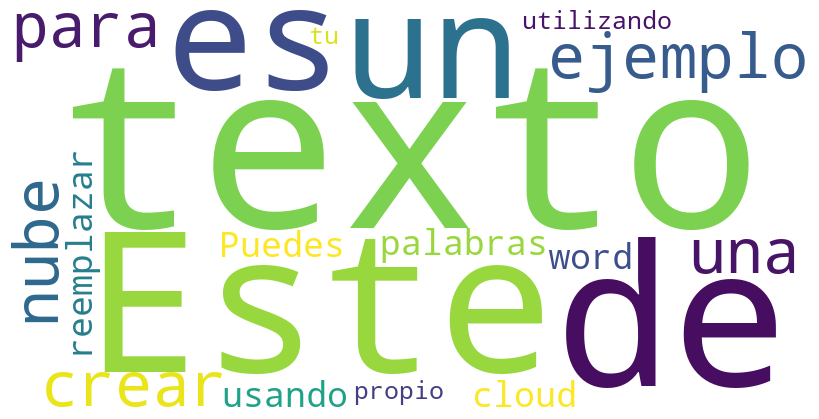

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



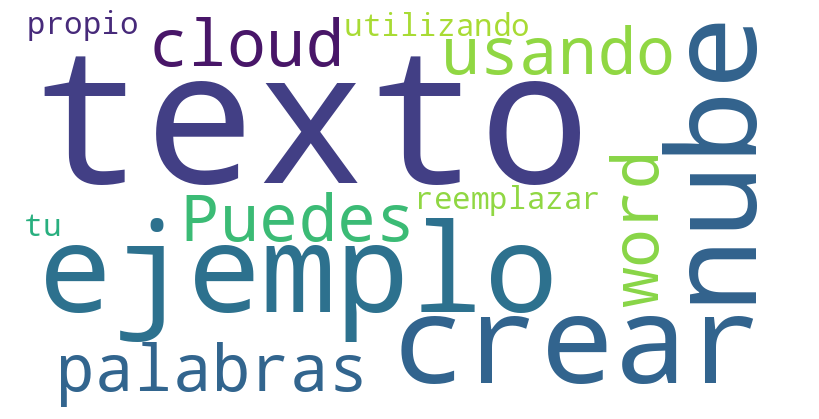

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
